<a href="https://colab.research.google.com/github/27Kushal/PyTorch-learning/blob/main/neural_network_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Make classification data and get it ready


In [ ]:
import sklearn

In [ ]:
from sklearn.datasets import make_circles

#make 1000 samples
n_samples=1000
#create circles
x,y=make_circles(n_samples,
                 noise=0.03,
                 random_state=42)

len(x),len(y)

(1000, 1000)

In [ ]:
print("First 5 samples of X:\n ",x[:5])
print("First 5 samples of Y: ",y[:5])

First 5 samples of X:
  [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of Y:  [1 1 1 1 0]


In [ ]:
#make dataframe of circle data
import pandas as pd
circles=pd.DataFrame({"X1":x[:,0],
                      "X2":x[:,1],
                     "label":y})

circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


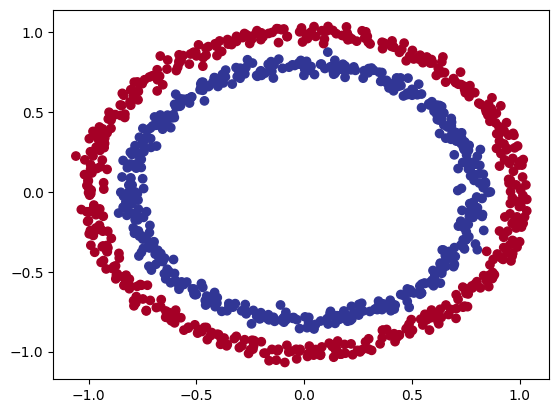

In [ ]:
#visualize
import matplotlib.pyplot as plt
plt.scatter(x=x[:,0],
            y=x[:,1],
            c=y,
            cmap=plt.cm.RdYlBu);

## 1.1 Check input and output shapes

In [ ]:
x.shape,y.shape

((1000, 2), (1000,))

##1.2 Turn data into tensors and create train and test splits

In [ ]:
import torch
torch.__version__

'2.10.0+cpu'

In [ ]:
type(x)

numpy.ndarray

In [ ]:
#turn data into tensors
X=torch.from_numpy(x).type(torch.float)
Y=torch.from_numpy(y).type(torch.float)
X[:5],Y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [ ]:
type(X)

torch.Tensor

In [ ]:
#split data into training and test sets
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2, random_state=42)


In [ ]:
len(x_train),len(x_test),len(y_train),len(y_test)

(800, 200, 800, 200)

#2. Building a model

Building a model to classify our blue and red dots

To do so, we want to:
1. Setup device agnostic code so our code will run on an accelerator (GPU) if available
2. Construct a model(by subclassing 'nn.module')
3. Define a loss function and optimizer
4. Create a training and test loop


In [ ]:
import torch
from torch import nn

device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

model will include:
1. subclasses nn.module
2. create 2 nn.Linear() layers that are capable of handling the shapes in our data
3. defines a forward() method that outlines the forward pass (or forward computation) of the model
4. Instantiate an instance of our model class and send it to the target device

In [ ]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    #create 2 nn.Linear layers
    self.layer_1=nn.Linear(in_features=2, out_features=5)#takes 2 features and scales to 5 features
    self.layer_2=nn.Linear(in_features=5,out_features=1)#takes 5 features from previous layer and outputs 1 feature
  #define forward pass
  def forward(self,x):
    return self.layer_2(self.layer_1(x)) #x->layer_1->layer_2->output

#instantiate an instance of our model class and send it to the target device
model_0=CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
#replicating the model using nn.sequential

model_0=nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.3955,  0.0775],
                      [ 0.1529,  0.0116],
                      [-0.6818, -0.6832],
                      [-0.5464,  0.1485],
                      [-0.0239,  0.3017]])),
             ('0.bias', tensor([ 0.6557,  0.1248,  0.4907, -0.5005, -0.3552])),
             ('1.weight',
              tensor([[-0.2224, -0.2415, -0.0870, -0.1081, -0.0678]])),
             ('1.bias', tensor([-0.3213]))])

In [ ]:
#make predictions
with torch.inference_mode():
  untrained_preds=model_0(x_test.to(device))
print(f"length of preds: {len(untrained_preds)}, Shape:{untrained_preds.shape}")
print(f"Length of test samples: {len(x_test)}, Shape: {x_test.shape}")
print(f"First 10 predictions: {untrained_preds[:10]}")
print(f"First 10 test samples: {y_test[:10]}")

length of preds: 200, Shape:torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])
First 10 predictions: tensor([[-0.4580],
        [-0.4591],
        [-0.4593],
        [-0.4576],
        [-0.4659],
        [-0.4665],
        [-0.4643],
        [-0.4661],
        [-0.4590],
        [-0.4592]])
First 10 test samples: tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


##2.1 Setup loss function and optimizers

Which loss function or optimizer should you use?
Again.. this is problem specific
* For example for regression you might want MAE or MSE(mean absolute error or mean squared error)
* For classification you might want binary cross entropy or categorical cross entropy(cross entropy)
* for optimizers most common ones are SGD and Adam

In [ ]:
#setup the loss function
loss_fn=nn.BCEWithLogitsLoss()# sigmoid activation function built in
#this is more stable than normal BCELoss
optimizer=torch.optim.SGD(params=model_0.parameters(),
                          lr=0.1)


In [ ]:
#calculate accuracy- out of 100 examples, what percentage does our model get right?
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=(correct/len(y_pred))*100
  return acc

#3. Train Model

To train a model, we need to create a training loop:
1. forward pass
2. calculate the loss
3. optimizer zero grad
4. loss backward(backpropagation)
5. optimizer step(gradient descent)


##3.1 Going from raw logits->prediction probablities->predition labels

* Our model outputs are given in form of raw logits.
* We can convert these **logits** into prediction probablities by passing them to some kind of activation function(e.g sigmoid for binary classification and softmax for multiclass classification).
* Then we can convert our model's prediction probabilities to prediction labels by either rounding them or taking the argmax()

In [ ]:
#view the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
  y_logits=model_0(x_test.to(device))[:5]
y_logits

tensor([[-0.4580],
        [-0.4591],
        [-0.4593],
        [-0.4576],
        [-0.4659]])

In [ ]:
#use the sigmoid activation function on our model logits to turn them into prediction probablities
y_pred_probs=torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.3875],
        [0.3872],
        [0.3872],
        [0.3876],
        [0.3856]])

For our prediction probability values, we need to perform a range style rounding on them:
* y_pred_probs>=0.5, y=1 (class 1)
* y_pred_probs<0.5, y=0 (class 0)

In [ ]:
#finding the predicted labels
y_preds=torch.round(y_pred_probs)

#In full
y_pred_labels=torch.round(torch.sigmoid(model_0(x_test.to(device))[:5]))

#Check for equality
print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))

#get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 0., 0., 0.])

##3.2 Building a training and testing loop

In [ ]:
torch.manual_seed(42)

epochs=100
x_train,y_train=x_train.to(device),y_train.to(device)
x_test,y_test=x_test.to(device),y_test.to(device)

#building training and evaluation loop
for epoch in range(epochs):
  #training
  model_0.train()
  #forward pass
  y_logits=model_0(x_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits)) #turn logits->pred probs->pred labels

  #calculate loss/accuracy
  loss=loss_fn(y_logits,y_train) #nn.BCEWithLogitsLoss expects raw logits as input
  acc=accuracy_fn(y_true=y_train,y_pred=y_pred)

  #optimizer zero grad
  optimizer.zero_grad()
  #loss backward(backpropagation)
  loss.backward()
  #optimizer step(gradient descent)
  optimizer.step()

  ##Testing
  model_0.eval()
  with torch.inference_mode():
    #forward pass
    test_logits=model_0(x_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))

    #calculate test loss/accuracy
    test_loss=loss_fn(test_logits,y_test)
    test_acc=accuracy_fn(y_true=y_test,y_pred=test_pred)

  if epoch%10==0:
    print(f"Epoch: {epoch}, Acc: {acc:.2f}, Test Loss: {test_loss:.5f}, Test acc: {test_acc:.2f}")

Epoch: 0, Acc: 50.00, Test Loss: 0.71678, Test acc: 50.00
Epoch: 10, Acc: 50.00, Test Loss: 0.70084, Test acc: 50.00
Epoch: 20, Acc: 50.00, Test Loss: 0.69550, Test acc: 50.00
Epoch: 30, Acc: 50.00, Test Loss: 0.69371, Test acc: 50.00
Epoch: 40, Acc: 43.50, Test Loss: 0.69312, Test acc: 47.00
Epoch: 50, Acc: 47.88, Test Loss: 0.69295, Test acc: 47.50
Epoch: 60, Acc: 48.62, Test Loss: 0.69294, Test acc: 47.00
Epoch: 70, Acc: 48.62, Test Loss: 0.69298, Test acc: 47.50
Epoch: 80, Acc: 49.62, Test Loss: 0.69304, Test acc: 47.00
Epoch: 90, Acc: 49.50, Test Loss: 0.69310, Test acc: 46.00


#4. Make predictions and evaluate the model

From the metrics it looks like the model is not learning anything,
So to inspect it let's make some predictions and make them visual
* To do so we're going to import a function called plot_decision_boundary()

In [ ]:
import requests
from pathlib import Path

#download helper functions from Learn Pytorch repo(if its not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("Downloading helper_functions.py")
  request=requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

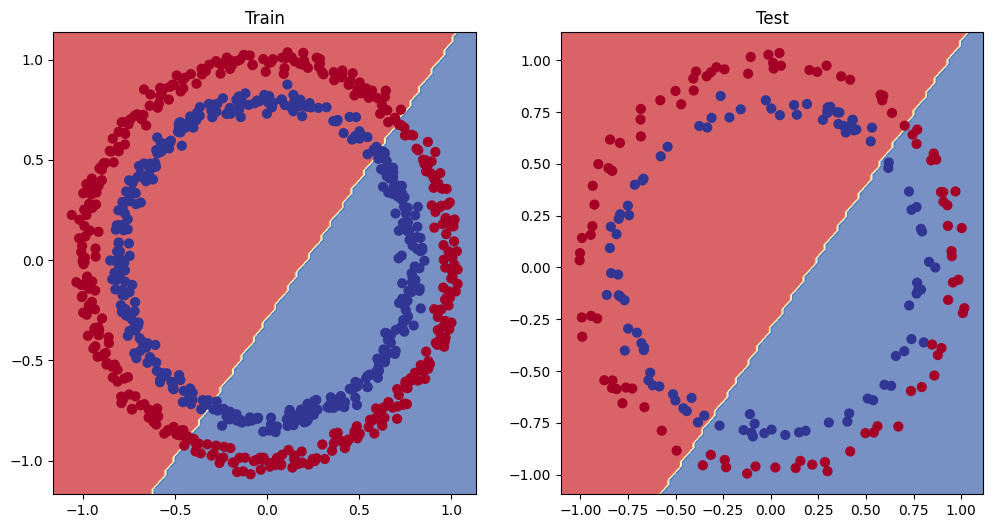

In [ ]:
#Plot decision boundary of model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,x_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,x_test,y_test)


#5. Improving a model(from model perspective)

* Add more layers-give the model more chances to learn about patterns in the data
* Add more hidden units- go from 5 to 10 hidden units
* Fit for longer
* Changing the activation function
* Change the learning rate
* Change the loss function

In [ ]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1=nn.Linear(in_features=2,out_features=10)
    self.layer_2=nn.Linear(in_features=10,out_features=10)
    self.layer_3=nn.Linear(in_features=10,out_features=1)
  def forward(self,x):
    return self.layer_3(self.layer_2(self.layer_1(x)))#this way of writing operations leverages speed ups where possible behind the scene

model_1=CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(params=model_1.parameters(),lr=0.1)

In [ ]:
torch.manual_seed(42)

epochs=1000

for epoch in range(epochs):
  model_1.train()
  y_logits=model_1(x_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))
  loss=loss_fn(y_logits,y_train)
  acc=accuracy_fn(y_true=y_train,y_pred=y_pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    test_logits=model_1(x_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))

    test_loss=loss_fn(test_logits,y_test)
    test_acc=accuracy_fn(y_true=y_test,y_pred=test_pred)

  if epoch%100==0:
    print(f"Epoch: {epoch}, Acc: {acc:.2f}, Test Loss: {test_loss:.5f}, Test acc: {test_acc:.2f}")

Epoch: 0, Acc: 50.88, Test Loss: 0.69261, Test acc: 51.00
Epoch: 100, Acc: 50.38, Test Loss: 0.69379, Test acc: 48.00
Epoch: 200, Acc: 51.12, Test Loss: 0.69437, Test acc: 46.00
Epoch: 300, Acc: 51.62, Test Loss: 0.69458, Test acc: 45.00
Epoch: 400, Acc: 51.12, Test Loss: 0.69465, Test acc: 46.00
Epoch: 500, Acc: 51.00, Test Loss: 0.69467, Test acc: 46.00
Epoch: 600, Acc: 51.00, Test Loss: 0.69468, Test acc: 46.00
Epoch: 700, Acc: 51.00, Test Loss: 0.69468, Test acc: 46.00
Epoch: 800, Acc: 51.00, Test Loss: 0.69468, Test acc: 46.00
Epoch: 900, Acc: 51.00, Test Loss: 0.69468, Test acc: 46.00


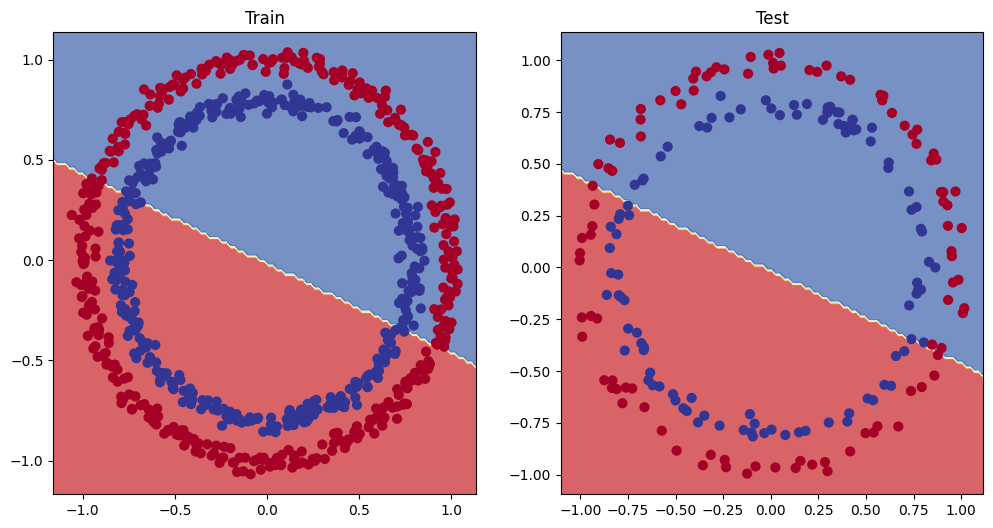

In [ ]:
#plot the decision boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,x_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1,x_test,y_test)


##5.1 Preparing data to see if our model can fit a straight line

One way to troubleshoot to a larger problem is to test out a smaller problem

In [ ]:
#Create some data(same as notebook 01)

weight=0.7
bias=0.3
start=0
end=1
step=0.01

x_regression=torch.arange(start,end,step).unsqueeze(dim=1)
y_regression=weight*x_regression+bias #linear regression formula(without epsilon)

#check the data
print(len(x_regression))
x_regression[:5],y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [ ]:
#create train and test splits
train_split=int(0.8*len(x_regression))
x_train_regression,y_train_regression=x_regression[:train_split],y_regression[:train_split]
x_test_regression,y_test_regression=x_regression[train_split:],y_regression[train_split:]

len(x_train_regression),len(y_train_regression),len(x_test_regression),len(y_test_regression)

(80, 80, 20, 20)

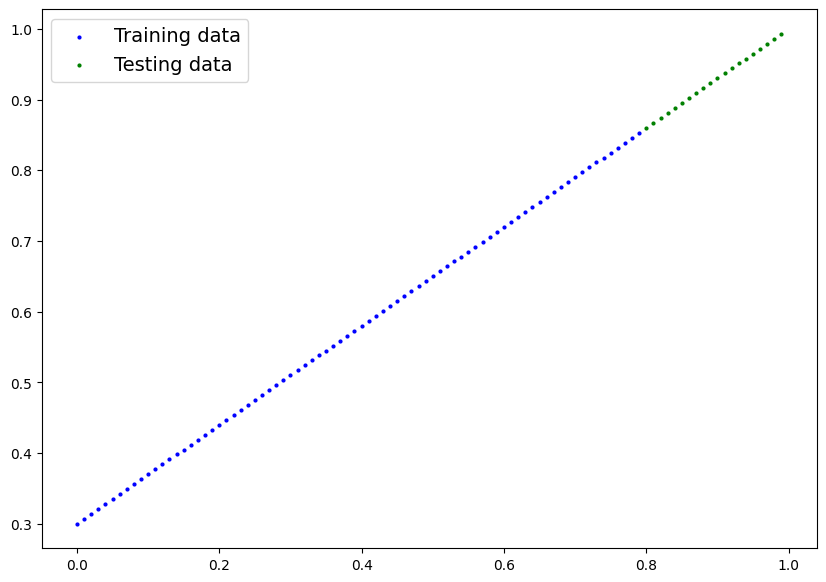

In [ ]:
plot_predictions(train_data=x_train_regression,
                 train_labels=y_train_regression,
                 test_data=x_test_regression,
                 test_labels=y_test_regression)

##5.2 Adjusting model_1 to fit a straight line

In [ ]:
#same architecture as model_1 (using nn.sequential)

model_2=nn.Sequential(
    nn.Linear(in_features=1,out_features=10),
    nn.Linear(in_features=10,out_features=10),
    nn.Linear(in_features=10,out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
#loss and optimizer
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(params=model_2.parameters(),lr=0.01)

In [ ]:
#train the model
torch.manual_seed(42)
epochs=1000

x_train_regression,y_train_regression=x_train_regression.to(device),y_train_regression.to(device)
x_test_regression,y_test_regression=x_test_regression.to(device),y_test_regression.to(device)

for epoch in range(epochs):
  model_2.train()
  y_pred=model_2(x_train_regression)
  loss=loss_fn(y_pred,y_train_regression)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_2.eval()
  with torch.inference_mode():
    test_pred=model_2(x_test_regression)
    test_loss=loss_fn(test_pred,y_test_regression)

  if epoch%100==0:
    print(f"Epoch: {epoch}, Loss: {loss:.5f}, Test Loss: {test_loss:.5f}")

Epoch: 0, Loss: 0.75986, Test Loss: 0.91103
Epoch: 100, Loss: 0.02858, Test Loss: 0.00081
Epoch: 200, Loss: 0.02533, Test Loss: 0.00209
Epoch: 300, Loss: 0.02137, Test Loss: 0.00305
Epoch: 400, Loss: 0.01964, Test Loss: 0.00341
Epoch: 500, Loss: 0.01940, Test Loss: 0.00387
Epoch: 600, Loss: 0.01903, Test Loss: 0.00379
Epoch: 700, Loss: 0.01878, Test Loss: 0.00381
Epoch: 800, Loss: 0.01840, Test Loss: 0.00329
Epoch: 900, Loss: 0.01798, Test Loss: 0.00360


#6. Missing Piece- non linearity

"What patterns could be drawn with infinite number of straight and non straight lines"

##6.1 Recreating non linear data(red and blue circles)

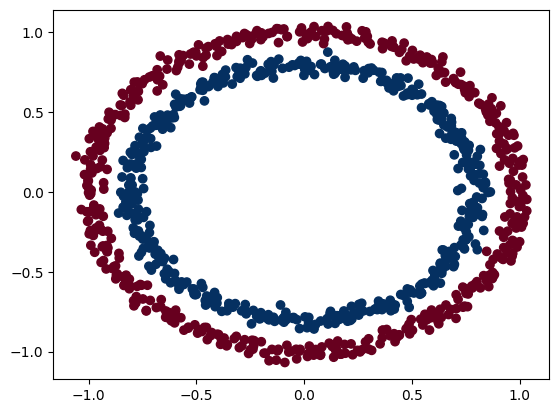

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples=1000

x,y=make_circles(n_samples,
                 noise=0.03,
                 random_state=42)

plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.RdBu);

In [ ]:
#convert data to tensors then train and test splits
import torch
from sklearn.model_selection import train_test_split
#turn data into tensors
x=torch.from_numpy(x).type(torch.float)
y=torch.from_numpy(y).type(torch.float)
#split into train and test splits
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


##6.2 Building a model with non-linearity

Artificial neural networks are a large combination of linear(straight) and non linear(non straight) functions which are potentially able to find patterns in data


In [ ]:
#Build a model with non-linear activation functions

from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1=nn.Linear(in_features=2,out_features=10)
    self.layer_2=nn.Linear(in_features=10,out_features=10)
    self.layer_3=nn.Linear(in_features=10,out_features=1)
    self.relu=nn.ReLU()

  def forward(self,x):
    #where should we put our non linear activation functions?
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3=CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(model_3.parameters(),lr=0.1)

##6.3 Training a model with non-linearity

In [ ]:
torch.manual_seed(42)

x_train,y_train=x_train.to(device),y_train.to(device)
x_test,y_test=x_test.to(device),y_test.to(device)

epochs=1000

for epoch in range(epochs):
  model_3.train()
  y_logits=model_3(x_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))
  loss=loss_fn(y_logits,y_train)
  acc=accuracy_fn(y_true=y_train,y_pred=y_pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_3.eval()
  with torch.inference_mode():
    test_logits=model_3(x_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))

    test_loss=loss_fn(test_logits,y_test)
    test_acc=accuracy_fn(y_true=y_test,y_pred=test_pred)
  if epoch%100==0:
    print(f"Epoch: {epoch}, Acc: {acc:.2f}, Test Loss: {test_loss:.5f}, Test acc: {test_acc:.2f}")

Epoch: 0, Acc: 50.00, Test Loss: 0.69319, Test acc: 50.00
Epoch: 100, Acc: 52.88, Test Loss: 0.69102, Test acc: 52.50
Epoch: 200, Acc: 53.37, Test Loss: 0.68940, Test acc: 55.00
Epoch: 300, Acc: 53.00, Test Loss: 0.68723, Test acc: 56.00
Epoch: 400, Acc: 52.75, Test Loss: 0.68411, Test acc: 56.50
Epoch: 500, Acc: 52.75, Test Loss: 0.67941, Test acc: 56.50
Epoch: 600, Acc: 54.50, Test Loss: 0.67285, Test acc: 56.00
Epoch: 700, Acc: 58.38, Test Loss: 0.66322, Test acc: 59.00
Epoch: 800, Acc: 64.00, Test Loss: 0.64757, Test acc: 67.50
Epoch: 900, Acc: 74.00, Test Loss: 0.62145, Test acc: 79.00


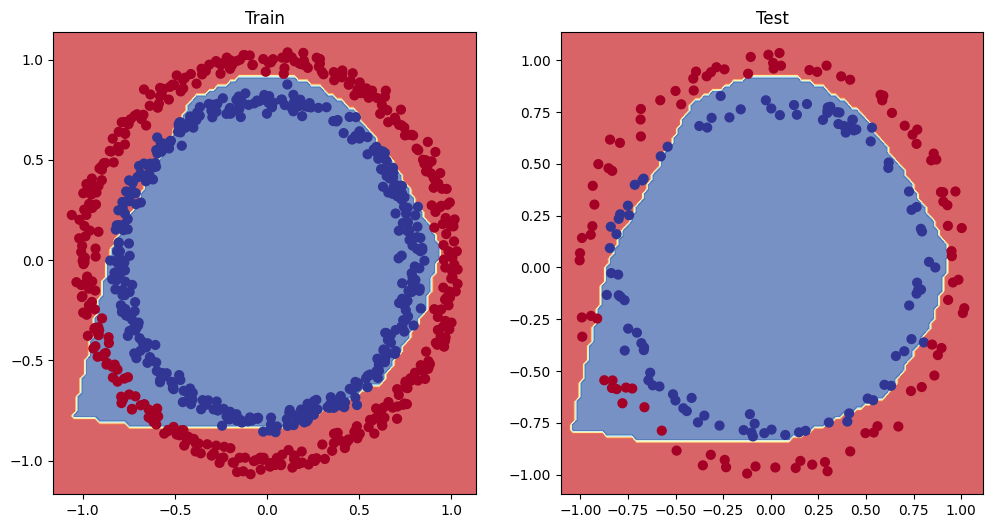

In [ ]:
#plot the decision boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_3,x_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3,x_test,y_test)


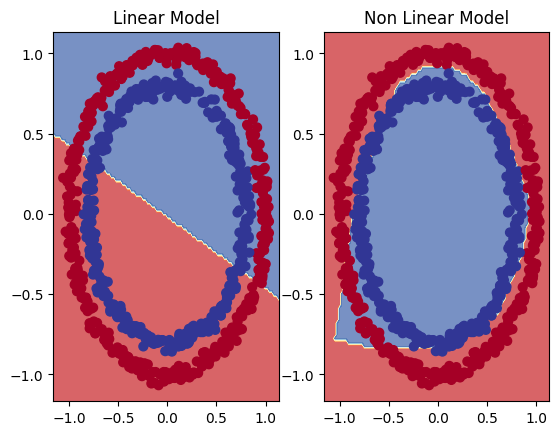

In [ ]:
#difference between linear and non linear model

plt.figurefigsize=(12,6)
plt.subplot(1,2,1)
plt.title("Linear Model")
plot_decision_boundary(model_1,x_train,y_train)
plt.subplot(1,2,2)
plt.title("Non Linear Model")
plot_decision_boundary(model_3,x_train,y_train)

#7. Replicating non-linear activation functions

Neural networks, rather than us telling the model what to learn, we give it the tools to discover patterns in data and it tries to figure out the patterns on its own

In [ ]:
#create a tensor
A=torch.arange(-10,10,1,dtype=torch.float32)
A.dtype

torch.float32

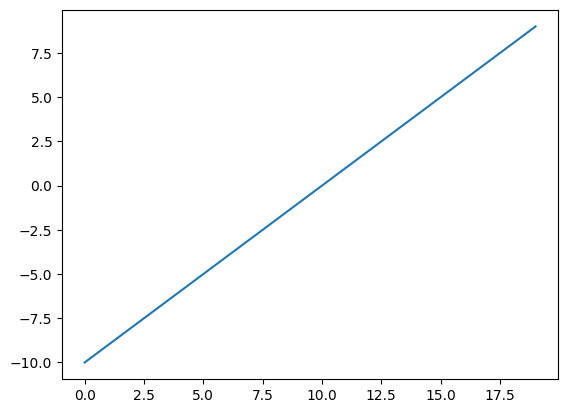

In [ ]:
#visualize
plt.plot(A)

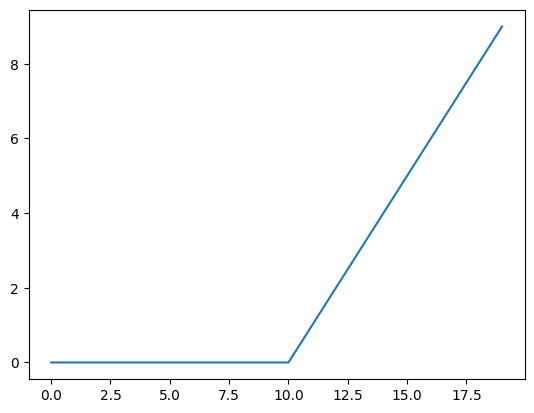

In [ ]:
plt.plot(torch.relu(A))

In [ ]:
def relu(x: torch.Tensor) -> torch.Tensor:
  return torch.maximum(torch.tensor(0),x) #inputs must be tensors

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

In [ ]:
#same thing for sigmoid
def sigmoid(x):
  return 1/(1+torch.exp(-x))

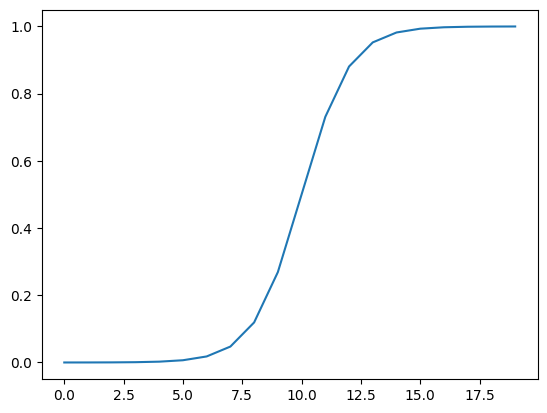

In [ ]:
plt.plot(torch.sigmoid(A))

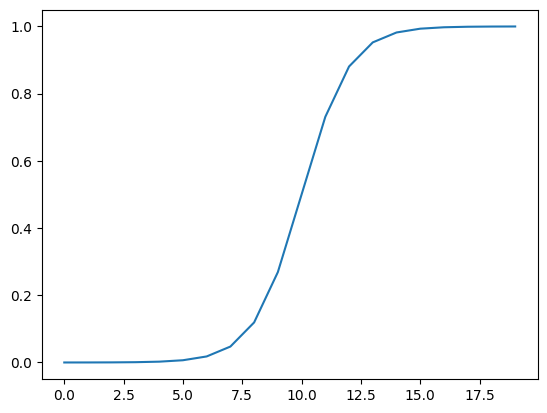

In [ ]:
plt.plot(sigmoid(A))

#8. Putting it all together with a multi class classification problem

##8.1 Creating a toy multi class dataset

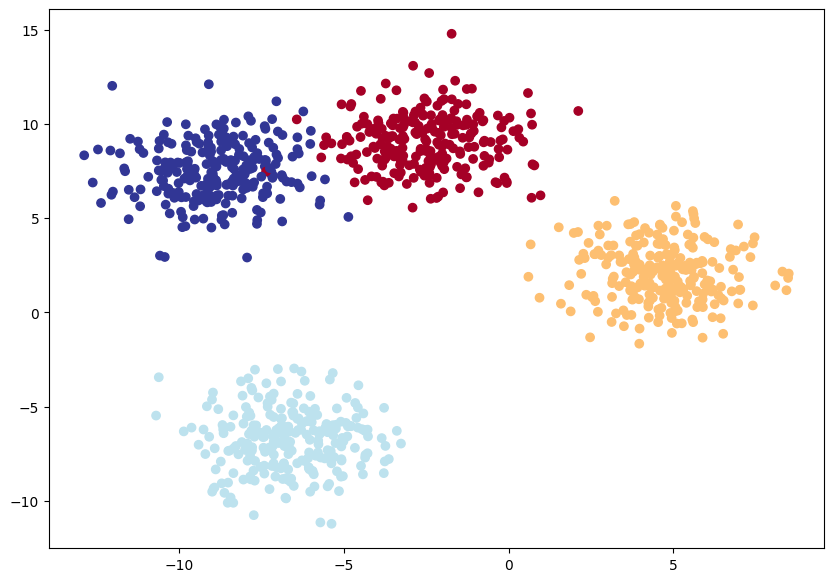

In [ ]:
#import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

#set hyperparameters for data creation
NUM_CLASSES=4
NUM_FEATURES=2
RANDOM_SEED=42

#create data
x_blob,y_blob=make_blobs(n_samples=1000,
                   n_features=NUM_FEATURES,
                   centers=NUM_CLASSES,
                   cluster_std=1.5, #give the clusters a little shake up
                   random_state=RANDOM_SEED)

#turn data into tensors
x_blob=torch.from_numpy(x_blob).type(torch.float)
y_blob=torch.from_numpy(y_blob).type(torch.LongTensor)

#split into train and test splits
x_blob_train,x_blob_test,y_blob_train,y_blob_test=train_test_split(x_blob,
                                                                   y_blob,
                                                                   test_size=0.2,
                                                                   random_state=RANDOM_SEED)

#plot data
plt.figure(figsize=(10,7))
plt.scatter(x=x_blob[:,0],
            y=x_blob[:,1],
            c=y_blob,
            cmap=plt.cm.RdYlBu)

##8.2 Building a multi-class classification model

In [ ]:
#build model
class BlobModel(nn.Module):
  def __init__(self,input_features,output_features,hidden_units=8):
    """Initialises multi-class classification model

    Args:
      input_features(int):Number of input features to the model
      output_features(int):Number of output features of the model
      hidden_units(int):Number of hidden units between layers,default=8
    """

    super().__init__()
    self.linear_layer_stack=nn.Sequential(
        nn.Linear(in_features=input_features,out_features=hidden_units),
        #nn.ReLU(),  we can implement relu if we want non linearity
        nn.Linear(in_features=hidden_units,out_features=hidden_units),
        #nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_features)
    )
  def forward(self,x):
    return self.linear_layer_stack(x)

model_4=BlobModel(input_features=2,
                  output_features=4,
                  hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

##8.3 Create loss function and optimizers

In [ ]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_4.parameters(),lr=0.1)

##8.4 getting prediction probabilities for a multi-class PyTorch model

Inorder to evaluate and train and test our model, we need to convert our model's outputs(logits) to prediction probabilities and then to prediction labels.


Logits (raw output of the model)-> pred probs(use torch.softmax)-> pred labels(take the argmax of the prediction probabilities)

In [ ]:
model_4.eval()
with torch.inference_mode():
  y_logits=model_4(x_blob_test.to(device))

y_logits[:5]

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]])

In [ ]:
#convert our model's logit outputs to prediction probabilities
y_pred_probs=torch.softmax(y_logits,dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])
# the output gives the individual probabilities of being that particular class

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]])
tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951]])


In [ ]:
#Convert our model's prediction probabilities to prediction labels
y_preds=torch.argmax(y_pred_probs,dim=1)
y_preds[:5]

tensor([3, 3, 2, 1, 3])

##8.5 creating training and testing loop

In [ ]:
torch.manual_seed(42)

epochs=100

x_blob_train,y_blob_train=x_blob_train.to(device),y_blob_train.to(device)
x_blob_test,y_blob_test=x_blob_test.to(device),y_blob_test.to(device)

for epoch in range(epochs):
  model_4.train()
  y_logits=model_4(x_blob_train)
  y_pred=torch.softmax(y_logits,dim=1).argmax(dim=1)
  loss=loss_fn(y_logits,y_blob_train)
  acc=accuracy_fn(y_true=y_blob_train,
                  y_pred=y_pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_4.eval()
  with torch.inference_mode():
    test_logits=model_4(x_blob_test)
    test_pred=torch.softmax(test_logits,dim=1).argmax(dim=1)
    test_loss=loss_fn(test_logits,y_blob_test)
    test_acc=accuracy_fn(y_true=y_blob_test,
                         y_pred=test_pred)
  if epoch%10==0:
    print(f"Epoch: {epoch}, Loss: {loss:.5f}, Acc: {acc:.2f}, Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}")


Epoch: 0, Loss: 1.04324, Acc: 65.50, Test Loss: 0.57861, Test Acc: 95.50
Epoch: 10, Loss: 0.14398, Acc: 99.12, Test Loss: 0.13037, Test Acc: 99.00
Epoch: 20, Loss: 0.08062, Acc: 99.12, Test Loss: 0.07216, Test Acc: 99.50
Epoch: 30, Loss: 0.05924, Acc: 99.12, Test Loss: 0.05133, Test Acc: 99.50
Epoch: 40, Loss: 0.04892, Acc: 99.00, Test Loss: 0.04098, Test Acc: 99.50
Epoch: 50, Loss: 0.04295, Acc: 99.00, Test Loss: 0.03486, Test Acc: 99.50
Epoch: 60, Loss: 0.03910, Acc: 99.00, Test Loss: 0.03083, Test Acc: 99.50
Epoch: 70, Loss: 0.03643, Acc: 99.00, Test Loss: 0.02799, Test Acc: 99.50
Epoch: 80, Loss: 0.03448, Acc: 99.00, Test Loss: 0.02587, Test Acc: 99.50
Epoch: 90, Loss: 0.03300, Acc: 99.12, Test Loss: 0.02423, Test Acc: 99.50


##8.6 Making and evaluating predictions with a pytorch multi class model

In [ ]:
model_4.eval()
with torch.inference_mode():
  y_logits=model_4(x_blob_test)

y_logits[:10]

tensor([[  4.3377,  10.3539, -14.8948,  -9.7642],
        [  5.0142, -12.0371,   3.3860,  10.6699],
        [ -5.5885, -13.3448,  20.9894,  12.7711],
        [  1.8400,   7.5599,  -8.6016,  -6.9942],
        [  8.0727,   3.2906, -14.5998,  -3.6186],
        [  5.5844, -14.9521,   5.0168,  13.2891],
        [ -5.9739, -10.1913,  18.8655,   9.9179],
        [  7.0755,  -0.7601,  -9.5531,   0.1736],
        [ -5.5918, -18.5990,  25.5310,  17.5799],
        [  7.3142,   0.7197, -11.2017,  -1.2011]])

In [ ]:
y_pred_probs=torch.softmax(y_logits,dim=1)
y_pred_probs[:10]

tensor([[2.4332e-03, 9.9757e-01, 1.0804e-11, 1.8271e-09],
        [3.4828e-03, 1.3697e-10, 6.8363e-04, 9.9583e-01],
        [2.8657e-12, 1.2266e-15, 9.9973e-01, 2.6959e-04],
        [3.2692e-03, 9.9673e-01, 9.5435e-08, 4.7619e-07],
        [9.9168e-01, 8.3089e-03, 1.4120e-10, 8.2969e-06],
        [4.5039e-04, 5.4287e-13, 2.5532e-04, 9.9929e-01],
        [1.6306e-11, 2.4030e-13, 9.9987e-01, 1.3003e-04],
        [9.9860e-01, 3.9485e-04, 5.9937e-08, 1.0045e-03],
        [3.0436e-14, 6.8303e-20, 9.9965e-01, 3.5218e-04],
        [9.9843e-01, 1.3657e-03, 9.0767e-09, 2.0006e-04]])

In [ ]:
y_preds=torch.argmax(y_pred_probs,dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

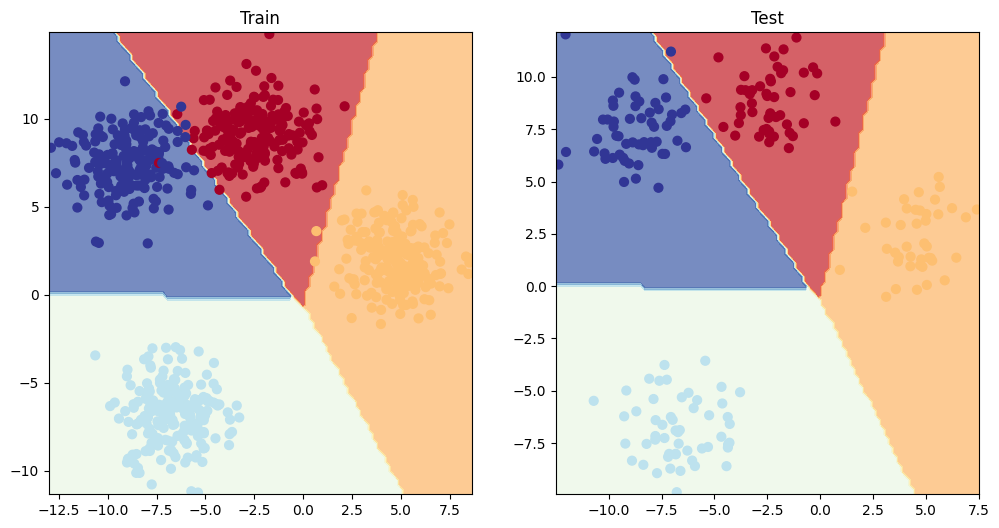

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4,x_blob_train,y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4,x_blob_test,y_blob_test)

#9. Few more classification metrics (to evaluate our model)

* Accuracy- out of 100 how many our model gets right
* Precision
* Recall
* F1 score
* Confusion matrix
* classification report


In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 19.8 MB/s eta 0:00:00


In [ ]:
from torchmetrics import Accuracy
#setup metric
torchmetric_accuracy=Accuracy(task='multiclass', num_classes=NUM_CLASSES).to(device)

torchmetric_accuracy(y_preds,y_blob_test)

tensor(0.9950)